In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from google.auth import default
from datetime import datetime, timedelta

In [70]:
credentials, project_id = default()
client = bigquery.Client(credentials=credentials, project=project_id)

In [71]:
df = client.query('''
  with dataset as (
  select
  created_at,
  user_id,
  extra,
  json_extract_scalar(extra,"$.sourceString") sourceString,
  amount,
  id
  from openloot-362008.postgres_rds_public.token_transactions
  where token_id='a07b874f-d30a-41d5-bfb1-879abf474590'
  and action='grant'
  and lower(json_extract_scalar(extra,"$.sourceString")) like "%heldbigtimereward.jackpot.%"
),

intermediate as (
  select
  date(a.created_at) Day,
  user_id,
  b.username,
  b.country_code,
  sourceString,
  count(distinct(a.id)) held_bigtime_reward_txs,
  sum(amount) dailyReward
  from dataset a
  left join openloot-362008.postgres_rds_auth_api_public.users  b on a.user_id=b.id
  group by 1,2,3,4,5
)

select
*
from intermediate
''').to_dataframe()

df.head()

,Day,user_id,username,country_code,sourceString,held_bigtime_reward_txs,dailyReward
0,2025-01-16,b31b8c5f-99f8-4414-8c03-27c87e2f093a,MoneyMoneyHome,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,1,30.000000
1,2025-03-13,202b747f-d95d-4158-9684-2aa1d185a769,Emituofo,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,1,616.000000
2,2025-03-14,c5e21750-aeb5-4545-b735-56bfc2f5187b,goda,DE,RollForLoot-tg.nftloottiers.heldbigtimereward....,1,470.000000
3,2025-05-16,fa0cd0fa-98b7-445f-bb71-902854c1cdae,Maritime,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,1,486.149978
4,2025-04-14,431525b0-750c-41e1-80aa-fab45c50ef54,ai16z,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,1,52.000000


In [72]:
# limit data
today = datetime.today()
thirty_days_ago = today - timedelta(days=30)
df_recent = df[df['Day'] > thirty_days_ago]
df_recent.columns

Index(['Day', 'user_id', 'username', 'country_code', 'sourceString',
       'held_bigtime_reward_txs', 'dailyReward'],
      dtype='object')

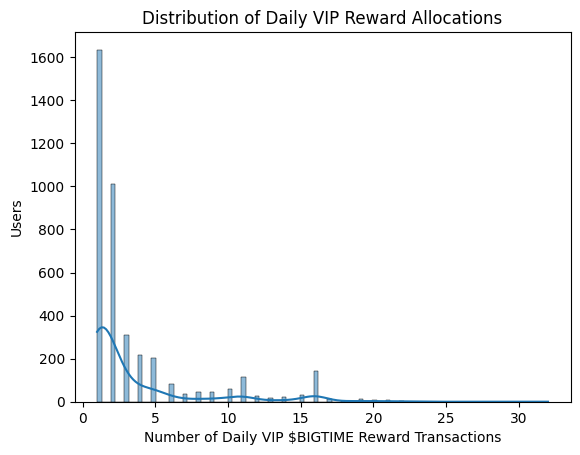

In [73]:
# histogram
sns.histplot(data=df_recent, x='held_bigtime_reward_txs', bins=100, kde=True)
plt.title('Distribution of Daily VIP Reward Allocations')
plt.xlabel('Number of Daily VIP $BIGTIME Reward Transactions')
plt.ylabel('Users')
plt.show()

In [74]:
# scan histogram
x= np.arange(0,1.05,.05)
df_recent['held_bigtime_reward_txs'].quantile(x)

,held_bigtime_reward_txs
0.00,1.0
0.05,1.0
0.10,1.0
0.15,1.0
0.20,1.0
0.25,1.0
0.30,1.0
0.35,1.0
0.40,1.0
0.45,2.0


In [75]:
#flag users
alert = df_recent['held_bigtime_reward_txs'].quantile(.90)
print(f'Recommend flagging users with >= {alert} multiple events per day')

Recommend flagging users with >= 11.0 multiple events per day


In [76]:
df_alert = df_recent[df_recent['held_bigtime_reward_txs'] > alert]
count_bad_users = df_alert['user_id'].nunique()
print(f'There are {count_bad_users} that meet this criteria over the last 30 days')

There are 68 that meet this criteria over the last 30 days


In [77]:
df_alert.to_csv('vip_users.csv')

In [78]:
df_alert.head()

,Day,user_id,username,country_code,sourceString,held_bigtime_reward_txs,dailyReward
165,2025-05-12,c7f78db6-7f10-4339-bfa4-fda8d41a6d8e,Fiona66,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,19,9287.249578
265,2025-05-13,c7f78db6-7f10-4339-bfa4-fda8d41a6d8e,Fiona66,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,19,9377.549574
383,2025-06-07,8c5acf78-c208-4bff-8c89-c5c77f66a2b3,Viper13,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,21,9837.000000
551,2025-06-09,8c5acf78-c208-4bff-8c89-c5c77f66a2b3,Viper13,CN,RollForLoot-tg.nftloottiers.heldbigtimereward....,22,10725.000000
784,2025-06-04,e80bdad3-7a82-42cb-b0c1-05fa34981a84,dalkaas,VN,RollForLoot-tg.nftloottiers.heldbigtimereward....,15,7406.000000


In [79]:
## groupby to get the punishment
df_bans = df_alert.groupby(['user_id','username','country_code']).agg({
    'Day': 'nunique',
    'held_bigtime_reward_txs':'sum',
    }).sort_values(by='held_bigtime_reward_txs',ascending=False
    ).reset_index()
df_bans = df_bans.rename(columns={
    'Day': 'unique_days',
    'held_bigtime_reward_txs': 'total_reward_txs'
})
df_bans['Suspended_Days'] = df_bans['total_reward_txs']-df_bans['unique_days']*2
df_bans.sort_values(by='Suspended_Days', ascending=False)
df_bans.to_csv('vip_bans.csv')